# STEP 02 — Energy Data Analysis (EDA)

Ebben a notebookban az idősorokat úgy vizsgáljuk, ahogyan egy RL environment tervezése előtt kell: nem csak „szép grafikonokat” készítünk, hanem azt keressük, **milyen döntési lehetőségeket és kockázatokat** teremtenek az ár-, demand- és renewable mintázatok.

In [1]:
from pathlib import Path
import sys, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
if ROOT.name == "workflow":
    ROOT = ROOT.parent
SRC = ROOT / "src"
for p in [ROOT, SRC]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from workflow.shared.utils import ensure_data, load_config, build_env

cfg = load_config()
full, train, val, test = ensure_data()
FIG_DIR = ROOT / "04_results" / "figures"
METRIC_DIR = ROOT / "04_results" / "metrics"
MODEL_DIR = ROOT / "04_results" / "models"
PRED_DIR = ROOT / "04_results" / "predictions"
for p in [FIG_DIR, METRIC_DIR, MODEL_DIR, PRED_DIR]:
    p.mkdir(parents=True, exist_ok=True)

QUICK_MODE = True  # GitHub notebookhoz gyors futás. Komolyabb benchmarkhoz állítsd False-ra.
SEEDS = [42, 123, 2026]
print(f"Project root: {ROOT}")
print(f"Rows: full={len(full):,}, train={len(train):,}, validation={len(val):,}, test={len(test):,}")

Project root: /mnt/data/smart_battery_energy_management_rl
Rows: full=8,760, train=6,132, validation=1,314, test=1,314


## 1. Adatminőség

RL-ben egy hibás időbélyeg, hiányzó óra vagy irreális negatív demand könnyen hibás transitionöket és félrevezető rewardot okozhat. Ezért az első lépés ugyanúgy data validation, mint supervised ML-nél.

In [2]:
quality = {
    "rows": len(full),
    "missing_cells": int(full.isna().sum().sum()),
    "duplicate_timestamps": int(full.timestamp.duplicated().sum()),
    "negative_demand_rows": int((full.electricity_demand_kw < 0).sum()),
    "negative_renewable_rows": int((full.renewable_generation_kw < 0).sum()),
    "timestamp_monotonic": bool(full.timestamp.is_monotonic_increasing),
}
pd.Series(quality, name="value")

rows                       8760
missing_cells                 0
duplicate_timestamps          0
negative_demand_rows          0
negative_renewable_rows       0
timestamp_monotonic        True
Name: value, dtype: object

## 2. Descriptive statistics

Különösen a szélsőértékek érdekesek: az RL policynek nem csak az átlagos órákban kell működnie. A `p95` és maximum értékek később a normalizálási skálák és stress testek megválasztásában is segítenek.

In [3]:
cols = ["electricity_price_eur_per_kwh", "electricity_demand_kw", "renewable_generation_kw"]
stats = full[cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
display(stats)

,count,mean,std,min,5%,25%,50%,75%,95%,max
electricity_price_eur_per_kwh,8760.0,0.127747,0.046785,0.032987,0.074306,0.094023,0.111635,0.155349,0.223237,0.266449
electricity_demand_kw,8760.0,55.391412,10.048660,27.757608,39.709981,48.235494,54.856851,62.212459,73.184796,85.450389
renewable_generation_kw,8760.0,14.311962,20.377445,0.000000,0.000000,0.000000,4.043561,20.546709,62.711256,84.353615


## 3. Electricity price distribution

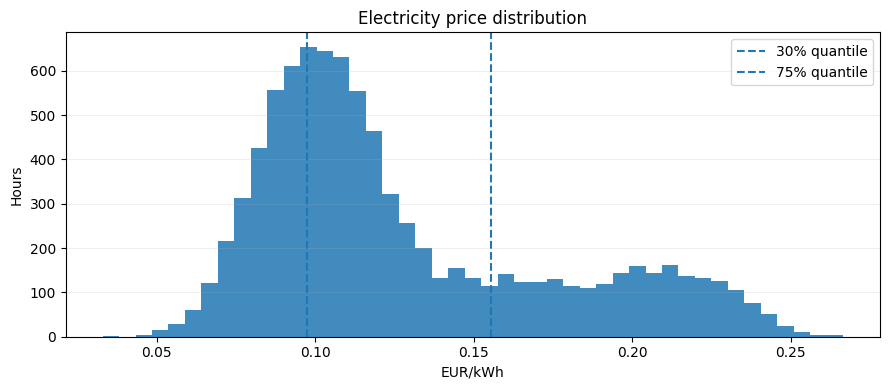

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(full["electricity_price_eur_per_kwh"], bins=45, alpha=0.85)
ax.axvline(full["electricity_price_eur_per_kwh"].quantile(0.30), linestyle="--", label="30% quantile")
ax.axvline(full["electricity_price_eur_per_kwh"].quantile(0.75), linestyle="--", label="75% quantile")
ax.set_title("Electricity price distribution")
ax.set_xlabel("EUR/kWh")
ax.set_ylabel("Hours")
ax.legend(); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb02_01_price_distribution.png", dpi=170, bbox_inches="tight")
plt.show()

A két kvantilis később a rule-based controller természetes küszöbe lehet. Ez nem azt jelenti, hogy ezek optimálisak; csak értelmezhető baseline-paraméterek.

## 4. Demand distribution és peak kockázat

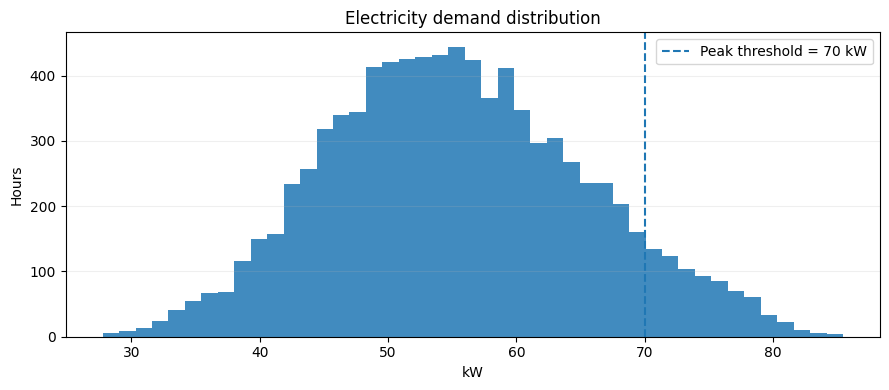

Hours above peak threshold: 762


In [5]:
peak_threshold = float(cfg["environment"]["peak_threshold_kw"])
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(full["electricity_demand_kw"], bins=45, alpha=0.85)
ax.axvline(peak_threshold, linestyle="--", label=f"Peak threshold = {peak_threshold:.0f} kW")
ax.set_title("Electricity demand distribution")
ax.set_xlabel("kW"); ax.set_ylabel("Hours"); ax.legend(); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb02_02_demand_distribution.png", dpi=170, bbox_inches="tight")
plt.show()
print("Hours above peak threshold:", int((full.electricity_demand_kw > peak_threshold).sum()))

## 5. Renewable generation distribution

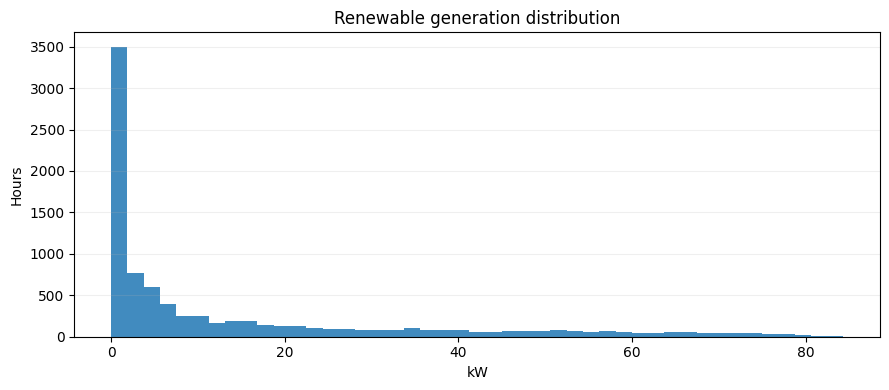

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(full["renewable_generation_kw"], bins=45, alpha=0.85)
ax.set_title("Renewable generation distribution")
ax.set_xlabel("kW"); ax.set_ylabel("Hours"); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb02_03_renewable_distribution.png", dpi=170, bbox_inches="tight")
plt.show()

## 6. Átlagos napi profilok

Ez az egyik legfontosabb EDA-ábra. Megmutatja, hogy egy „tipikus” napon mely órákban drágább az energia, mikor magasabb a demand és mikor érkezik renewable. A policynek ezeket a struktúrákat úgy kell kihasználnia, hogy közben a SOC dinamikája is korlátozza.

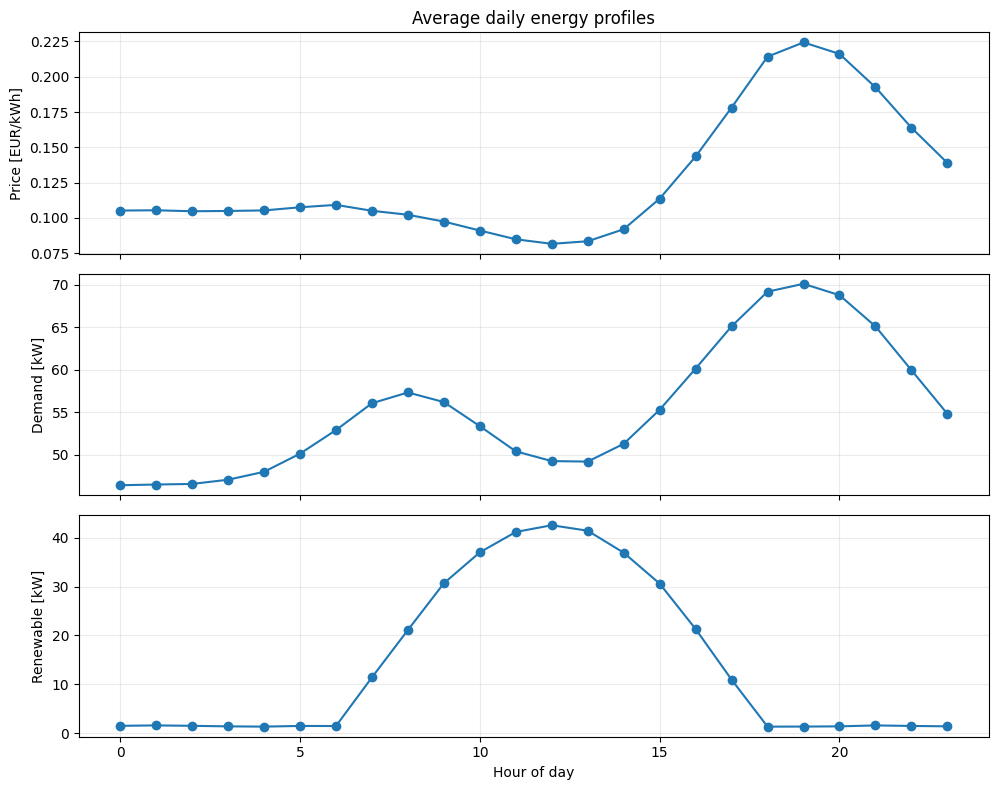

In [7]:
hourly = full.groupby("hour_of_day")[["electricity_price_eur_per_kwh", "electricity_demand_kw", "renewable_generation_kw"]].mean()
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, col, label in zip(axes, hourly.columns, ["Price [EUR/kWh]", "Demand [kW]", "Renewable [kW]"]):
    ax.plot(hourly.index, hourly[col], marker="o")
    ax.set_ylabel(label); ax.grid(alpha=0.25)
axes[0].set_title("Average daily energy profiles")
axes[-1].set_xlabel("Hour of day")
fig.tight_layout(); fig.savefig(FIG_DIR / "nb02_04_average_daily_profiles.png", dpi=170, bbox_inches="tight")
plt.show()

## 7. Net load — amit az akkumulátor ténylegesen „lát”

Battery nélkül a hálózat felé jelentkező nettó igény közelítőleg `demand - renewable`. Ha ez magas, a kisütés peak shavinget adhat. Ha alacsony vagy negatív, a töltés növelheti a renewable self-consumptiont.

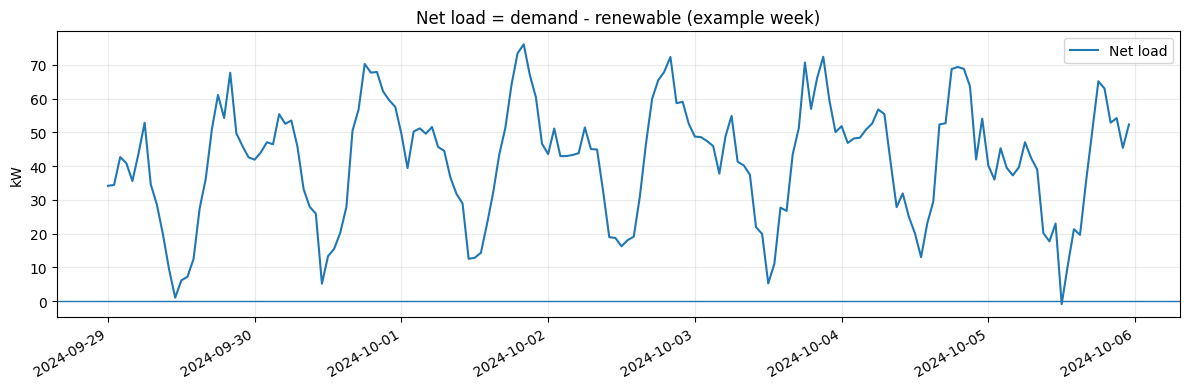

In [8]:
full_eda = full.copy()
full_eda["net_load_kw"] = full_eda["electricity_demand_kw"] - full_eda["renewable_generation_kw"]
week = full_eda.iloc[24*90:24*97]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(week.timestamp, week.net_load_kw, label="Net load")
ax.axhline(0, linewidth=1)
ax.set_title("Net load = demand - renewable (example week)")
ax.set_ylabel("kW"); ax.grid(alpha=0.25); ax.legend()
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(FIG_DIR / "nb02_05_net_load.png", dpi=170, bbox_inches="tight")
plt.show()

## 8. Korreláció — hasznos, de nem policy

A korreláció statikus lineáris kapcsolatot mér. Az RL policy ezzel szemben state- és időfüggő döntési szabály. Ettől függetlenül a korreláció segít felismerni, hogy például a price és demand mennyire mozog együtt.

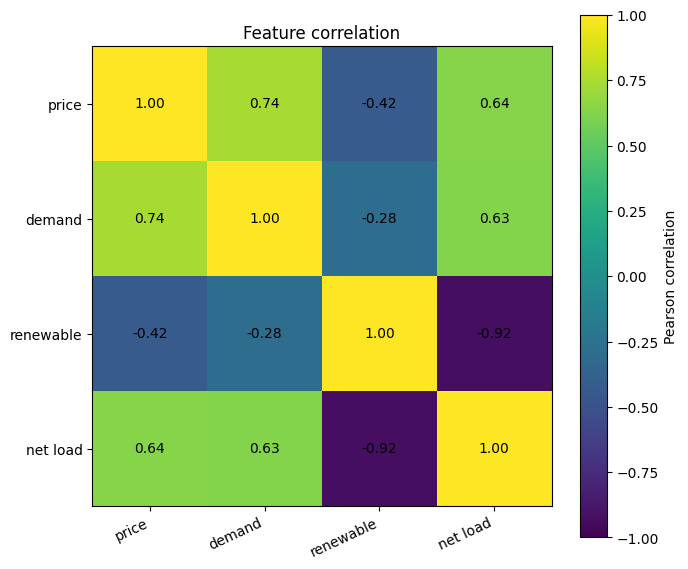

In [9]:
corr_cols = ["electricity_price_eur_per_kwh", "electricity_demand_kw", "renewable_generation_kw", "net_load_kw"]
corr = full_eda[corr_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)), ["price", "demand", "renewable", "net load"], rotation=25, ha="right")
ax.set_yticks(range(len(corr_cols)), ["price", "demand", "renewable", "net load"])
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center")
fig.colorbar(im, ax=ax, label="Pearson correlation")
ax.set_title("Feature correlation")
fig.tight_layout(); fig.savefig(FIG_DIR / "nb02_06_correlation.png", dpi=170, bbox_inches="tight")
plt.show()

## 9. Price vs net load

Ha a drága órák gyakran magas nettó demanddal esnek egybe, akkor a kisütés egyszerre csökkentheti az energia-költséget és a peak penaltyt.

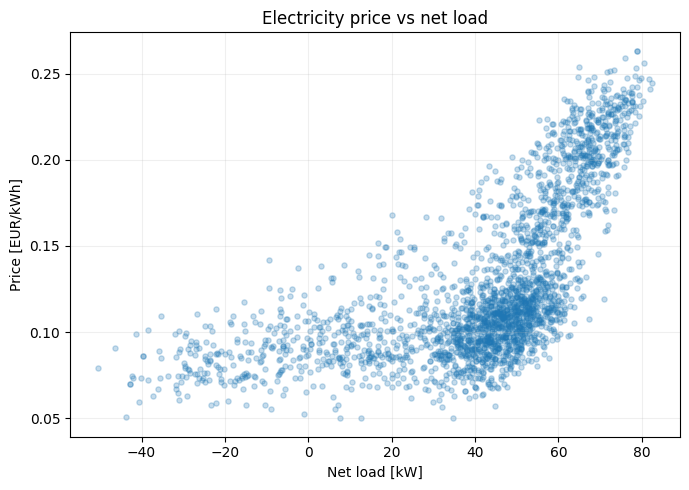

In [10]:
sample_scatter = full_eda.sample(min(2500, len(full_eda)), random_state=42)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(sample_scatter.net_load_kw, sample_scatter.electricity_price_eur_per_kwh, alpha=0.25, s=14)
ax.set_xlabel("Net load [kW]"); ax.set_ylabel("Price [EUR/kWh]")
ax.set_title("Electricity price vs net load")
ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb02_07_price_vs_netload.png", dpi=170, bbox_inches="tight")
plt.show()

## 10. Ár eloszlása óránként

Az átlag önmagában elrejti a volatilitást. A boxplotból látszik, hogy egy adott napszak mennyire stabil vagy változó ártartományt produkál.

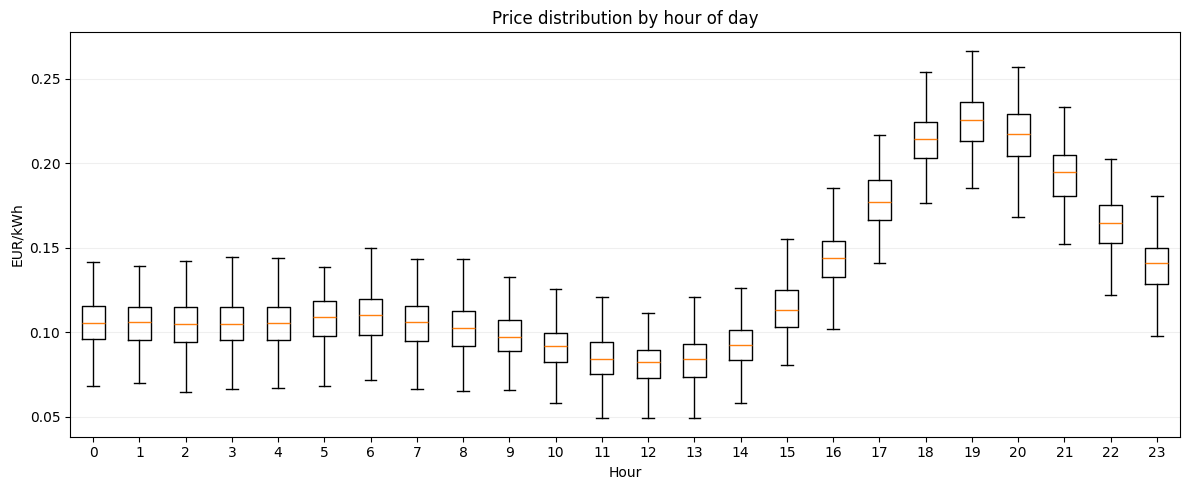

In [11]:
groups = [full.loc[full.hour_of_day == h, "electricity_price_eur_per_kwh"].values for h in range(24)]
fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(groups, positions=np.arange(24), showfliers=False)
ax.set_title("Price distribution by hour of day")
ax.set_xlabel("Hour"); ax.set_ylabel("EUR/kWh"); ax.grid(axis="y", alpha=0.2)
fig.tight_layout(); fig.savefig(FIG_DIR / "nb02_08_price_by_hour.png", dpi=170, bbox_inches="tight")
plt.show()

## 11. Peak threshold túllépések időben

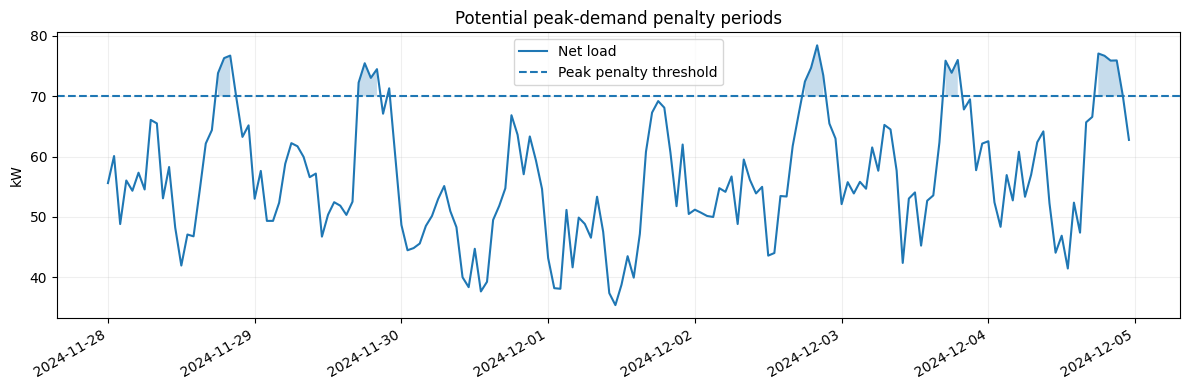

In [12]:
peak_week = full_eda.iloc[24*150:24*157]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(peak_week.timestamp, peak_week.net_load_kw, label="Net load")
ax.axhline(peak_threshold, linestyle="--", label="Peak penalty threshold")
ax.fill_between(peak_week.timestamp, peak_week.net_load_kw, peak_threshold, where=peak_week.net_load_kw > peak_threshold, alpha=0.25)
ax.set_title("Potential peak-demand penalty periods")
ax.set_ylabel("kW"); ax.legend(); ax.grid(alpha=0.2)
fig.autofmt_xdate(); fig.tight_layout(); fig.savefig(FIG_DIR / "nb02_09_peak_periods.png", dpi=170, bbox_inches="tight")
plt.show()

## 12. EDA következtetések az environmenthez

- Az árnak van időbeli struktúrája → van értelme arbitrage döntésnek.
- A demand és net load csúcsai indokolják a peak penalty komponenst.
- A renewable termelés időben erősen strukturált → a SOC és renewable együtt fontos state.
- A distribution shift reális kockázat → később külön stress testeket végzünk.
- A rule-based controllerhez használhatunk árkvantiliseket, de ezek csak baseline-ok, nem „igaz válaszok”.